In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Load Dataset

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Explore Dataset

print(df.shape)

print(df.info())

print(df.describe())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

In [4]:
# Check Missing Values

print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


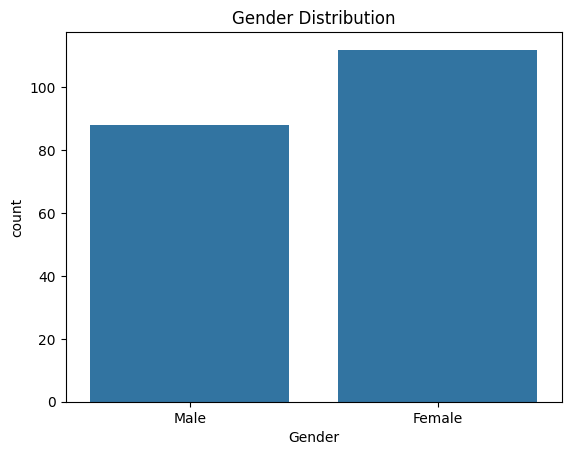

In [5]:
# Customer Distribution by Gender

sns.countplot(
    x='Gender',
    data=df
)

plt.title("Gender Distribution")
plt.show()

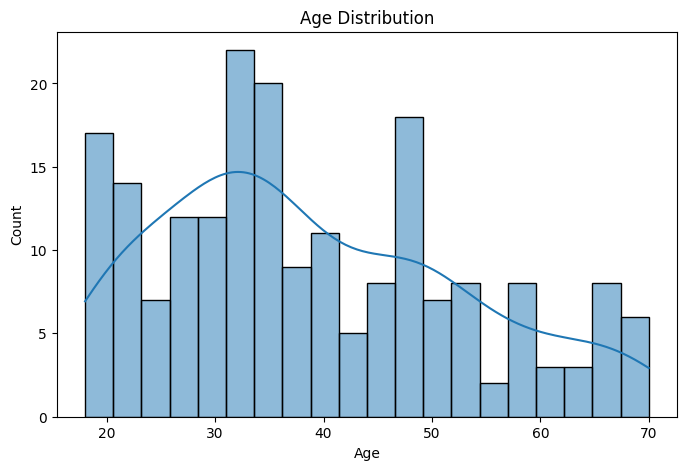

In [6]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

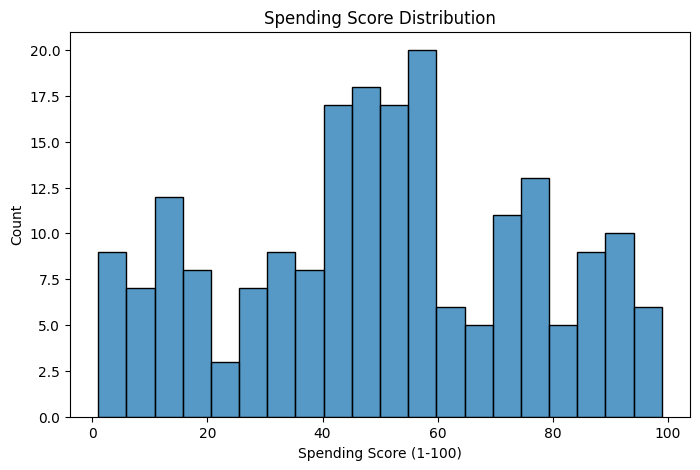

In [7]:
# Spending Score Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=20
)

plt.title("Spending Score Distribution")
plt.show()

In [8]:
# Select Features

X = df[
    [
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
]

In [9]:
# Scale Features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
# Elbow Method

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

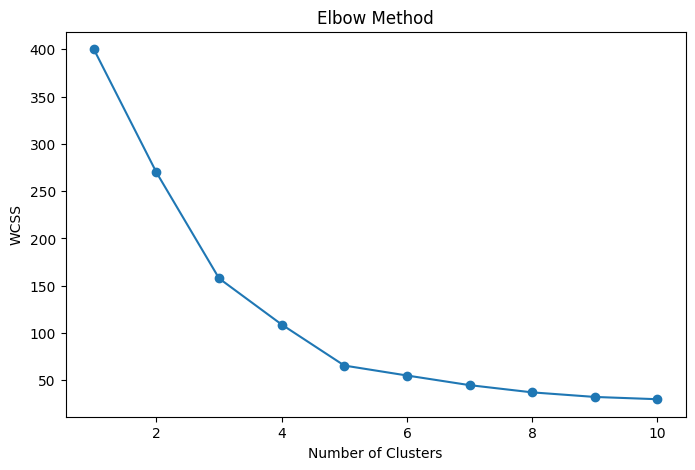

In [11]:
# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [12]:
# Apply K-Means

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [13]:
# Add Cluster Labels

df['Cluster'] = clusters

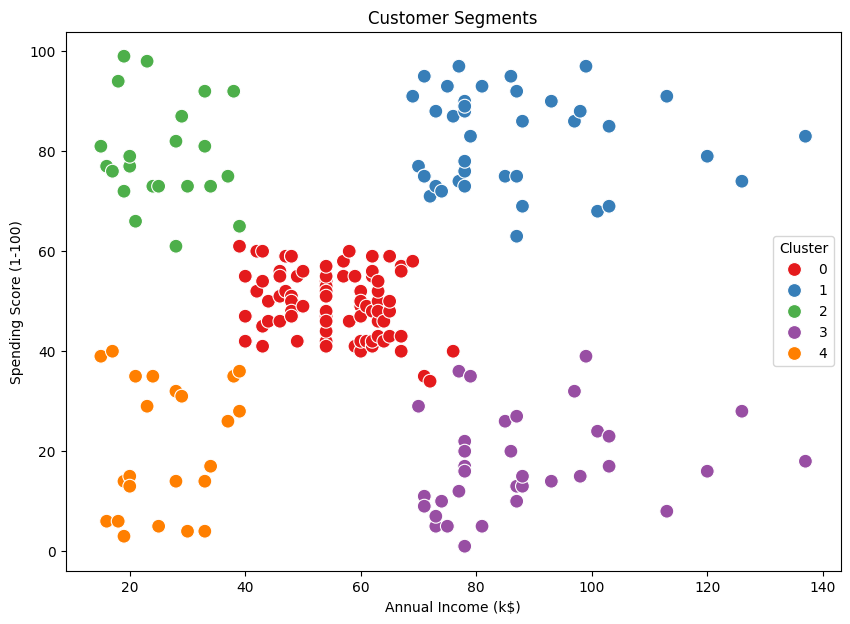

In [14]:
# Visualize Clusters

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Customer Segments")
plt.show()

In [15]:
# Cluster Profile

cluster_profile = df.groupby(
    'Cluster'
)[
    [
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
].mean()

print(cluster_profile)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [16]:
# Save Cluster Labels

df.to_csv(
    "customer_clusters.csv",
    index=False
)

print("File Saved")

File Saved


In [17]:
# Segment Report

for cluster in sorted(df['Cluster'].unique()):

    segment = df[
        df['Cluster'] == cluster
    ]

    print("\nCluster", cluster)

    print(
        "Average Age:",
        round(segment['Age'].mean(),2)
    )

    print(
        "Average Income:",
        round(segment['Annual Income (k$)'].mean(),2)
    )

    print(
        "Average Spending:",
        round(segment['Spending Score (1-100)'].mean(),2)
    )


Cluster 0
Average Age: 42.72
Average Income: 55.3
Average Spending: 49.52

Cluster 1
Average Age: 32.69
Average Income: 86.54
Average Spending: 82.13

Cluster 2
Average Age: 25.27
Average Income: 25.73
Average Spending: 79.36

Cluster 3
Average Age: 41.11
Average Income: 88.2
Average Spending: 17.11

Cluster 4
Average Age: 45.22
Average Income: 26.3
Average Spending: 20.91
